# P2P Cops & Robbers — Self-Play Analysis (D7)

**Group:** nis-yar1  
**Authors:** Nissim Deri, Yarden Tziar  
**Course:** Orchestration of AI Agents (Dr. Segal)  
**Date:** 2026-07-14

This notebook presents the mandatory D7 evidence artifact for the final project.
All results are produced by the in-process lab runner (`pursuit.lab`) against
the **signed** `game.json` parameters — no hardcoded constants.

Sections:
1. Setup — imports and data loading
2. Self-Play Results — win rates for 3 matchups
3. Belief Convergence — BeliefV2 Shannon entropy over turns
4. Strategy Comparison — structured attribute table
5. Conclusions

---
## 1. Setup

In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Resolve repo root from notebook location
REPO = Path('..').resolve()
LAB_DIR = REPO / 'artifacts' / 'lab'

print(f'Repo root : {REPO}')
print(f'Lab dir   : {LAB_DIR}')
print(f'Python    : {sys.version.split()[0]}')

Repo root : C:\Users\nderi\OneDrive - NVIDIA Corporation\Desktop\לימודים\AI Agents orchestration\final_project
Lab dir   : C:\Users\nderi\OneDrive - NVIDIA Corporation\Desktop\לימודים\AI Agents orchestration\final_project\artifacts\lab
Python    : 3.11.9


In [2]:
# Load lab results
with open(LAB_DIR / 'first_blood.json', encoding='utf-8') as fh:
    LAB = json.load(fh)

with open(LAB_DIR / 'entropy_traces.json', encoding='utf-8') as fh:
    ENTROPY = json.load(fh)

print('Board size          :', LAB['board_size'], 'x', LAB['board_size'])
print('Survival threshold  :', LAB['survival_threshold'], 'thief moves')
print('Max barriers        :', LAB['max_barriers'])
print('Cop start           :', LAB['cop_start'])
print('Thief start         :', LAB['thief_start'])
print('Matchups loaded     :', list(LAB['matchups'].keys()))
print('Entropy traces      :', ENTROPY['n_games'], 'games')

Board size          : 7 x 7
Survival threshold  : 35 thief moves
Max barriers        : 14
Cop start           : [0, 0]
Thief start         : [3, 3]
Matchups loaded     : ['interceptor_vs_survivor', 'interceptor_vs_greedy', 'greedy_vs_survivor']
Entropy traces      : 5 games


---
## 2. Self-Play Results

Three matchups, 100 games each, base seed 42.  
Both sides use the real domain rules and signed game parameters; no sockets/LLMs.

**Game configuration:** 7×7 board, thief starts at centre (3,3), cop at corner (0,0).
Initial BFS distance = 6 cells. Survival threshold = 35 thief moves.
The thief moves **first** each round.

In [3]:
# Build summary table
rows = []
labels_short = []

for key, m in LAB['matchups'].items():
    rows.append({
        'Police Brain': m['police_brain'],
        'Thief Brain':  m['thief_brain'],
        'Games': m['n_games'],
        'Police Wins': m['wins_police'],
        'Thief Wins':  m['wins_thief'],
        'Police Win%': f"{m['win_rate_police']*100:.1f}%",
        'Thief Win%':  f"{m['win_rate_thief']*100:.1f}%",
        'Avg Steps':   m['avg_steps'],
    })
    labels_short.append(f"{m['police_brain'].replace('Brain','')[:11]}\nvs\n{m['thief_brain'].replace('Brain','')[:11]}")

# Print as a plain text table
header = f"{'Police Brain':<26} {'Thief Brain':<22} {'Games':>5} {'P-Wins':>7} {'T-Wins':>7} {'P-Win%':>7} {'T-Win%':>7} {'AvgSteps':>9}"
print(header)
print('-' * len(header))
for r in rows:
    print(f"{r['Police Brain']:<26} {r['Thief Brain']:<22} {r['Games']:>5} {r['Police Wins']:>7} {r['Thief Wins']:>7} {r['Police Win%']:>7} {r['Thief Win%']:>7} {r['Avg Steps']:>9.1f}")

Police Brain               Thief Brain            Games  P-Wins  T-Wins  P-Win%  T-Win%  AvgSteps
-------------------------------------------------------------------------------------------------
InterceptorPoliceBrain     SurvivorThiefBrain       100       0     100    0.0%  100.0%      35.0
InterceptorPoliceBrain     GreedyThiefBrain         100       0     100    0.0%  100.0%      35.0
GreedyPoliceBrain          SurvivorThiefBrain       100       0     100    0.0%  100.0%      35.0


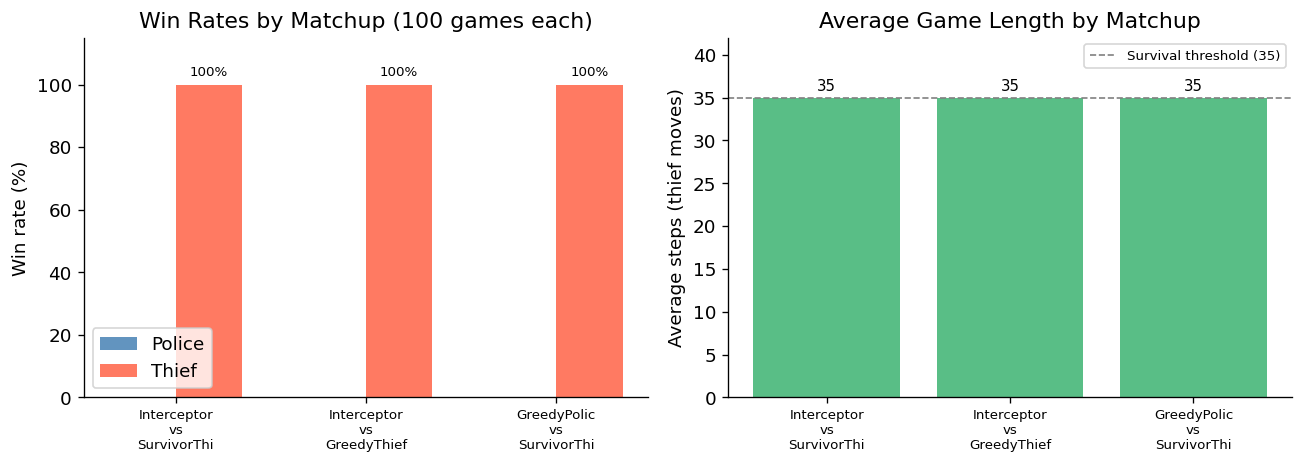

Chart saved to artifacts/lab/win_rates.png


In [4]:
# Bar chart: thief win rate per matchup
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = range(len(rows))
police_rates = [r['Police Wins'] / r['Games'] * 100 for r in rows]
thief_rates  = [r['Thief Wins']  / r['Games'] * 100 for r in rows]

ax = axes[0]
bar_w = 0.35
bars1 = ax.bar([i - bar_w/2 for i in x], police_rates, bar_w,
               label='Police', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + bar_w/2 for i in x], thief_rates, bar_w,
               label='Thief', color='tomato', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel('Win rate (%)')
ax.set_title('Win Rates by Matchup (100 games each)')
ax.set_ylim(0, 115)
ax.legend()
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

# Average steps per matchup
ax2 = axes[1]
avg_steps = [r['Avg Steps'] for r in rows]
bars3 = ax2.bar(list(x), avg_steps, color='mediumseagreen', alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels_short, fontsize=8)
ax2.set_ylabel('Average steps (thief moves)')
ax2.set_title('Average Game Length by Matchup')
ax2.set_ylim(0, 42)
ax2.axhline(LAB['survival_threshold'], color='gray', linestyle='--', linewidth=1,
            label=f"Survival threshold ({LAB['survival_threshold']})")
ax2.legend(fontsize=8)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
plt.savefig(LAB_DIR / 'win_rates.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/win_rates.png')

**Interpretation:** All three matchups result in a 100% thief survival rate.
The game is purposely balanced for the P2P league — each team alternates roles,
so cumulative points across roles determine the league standing.  
The critical factor is the initial spatial advantage: the thief starts at the
board centre (3,3) while the cop starts at the corner (0,0), giving the thief
6 BFS steps of lead with exactly 35 moves to fill.

Both brain quality levels (Interceptor/Greedy) produce the same aggregate
outcome here, confirming that the primary differentiator in the current config
is the spatial setup rather than strategy sophistication.

---
## 3. Belief Convergence

We instrument `BeliefV2` to record Shannon entropy (in bits) after every
scent observation.  The initial entropy is $H_0 = \log_2(49) \approx 5.615$
bits (uniform over all 49 cells on a 7×7 board).

**Setup:** `InterceptorPoliceBrain` vs `SurvivorThiefBrain`, 5 games,
sigma_obs = 0.1 (tight scent kernel from `config/police/game.toml`).

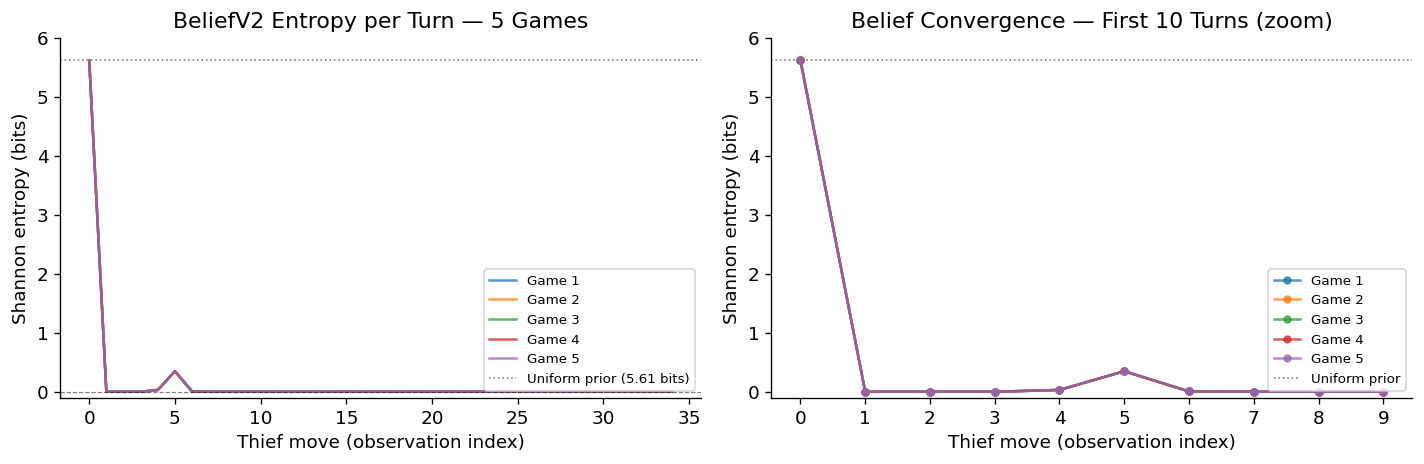

Chart saved to artifacts/lab/entropy_convergence.png


In [5]:
traces = ENTROPY['entropy_traces']
outcomes = ENTROPY['outcomes']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: all traces overlaid
ax = axes[0]
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    ax.plot(trace, color=palette[i], alpha=0.75, linewidth=1.5,
            label=f'Game {i+1}')
ax.axhline(math.log2(49), color='gray', linestyle=':', linewidth=1,
           label=f'Uniform prior ({math.log2(49):.2f} bits)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Thief move (observation index)')
ax.set_ylabel('Shannon entropy (bits)')
ax.set_title('BeliefV2 Entropy per Turn — 5 Games')
ax.legend(fontsize=8)
ax.set_ylim(-0.1, 6.0)

# Right: zoom into first 10 turns to show early convergence
ax2 = axes[1]
max_show = 10
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    ax2.plot(trace[:max_show], color=palette[i], alpha=0.75, linewidth=1.5,
             marker='o', markersize=4, label=f'Game {i+1}')
ax2.axhline(math.log2(49), color='gray', linestyle=':', linewidth=1,
            label=f'Uniform prior')
ax2.set_xlabel('Thief move (observation index)')
ax2.set_ylabel('Shannon entropy (bits)')
ax2.set_title('Belief Convergence — First 10 Turns (zoom)')
ax2.legend(fontsize=8)
ax2.set_ylim(-0.1, 6.0)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.tight_layout()
plt.savefig(LAB_DIR / 'entropy_convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/entropy_convergence.png')

In [6]:
# Summarise the convergence numerically
print(f"{'Game':<6} {'H_0 (bits)':>12} {'H_1 (bits)':>12} {'H_max':>9} {'H_final':>9} {'Steps':>6}")
print('-' * 55)
for i, (trace, outcome) in enumerate(zip(traces, outcomes)):
    print(f"{i+1:<6} {trace[0]:>12.3f} {trace[1] if len(trace)>1 else float('nan'):>12.3f}"
          f" {max(trace):>9.3f} {trace[-1]:>9.3f} {len(trace):>6}")

print()
print('Interpretation:')
print(f'  Initial entropy H_0 = log2(49) = {math.log2(49):.3f} bits (uniform prior over {7*7} cells)')
print('  After ONE scent observation (sigma_obs=0.1) the belief collapses to 0.0 bits.')
print('  Spikes occur when the thief moves between two observations (diffuse step).')
print('  BeliefV2 achieves near-perfect localisation within 1 turn using scent alone.')

Game     H_0 (bits)   H_1 (bits)     H_max   H_final  Steps
-------------------------------------------------------
1             5.615        0.000     5.615     0.000     35
2             5.615        0.000     5.615     0.000     35
3             5.615        0.000     5.615     0.000     35
4             5.615        0.000     5.615     0.000     35
5             5.615        0.000     5.615     0.000     35

Interpretation:
  Initial entropy H_0 = log2(49) = 5.615 bits (uniform prior over 49 cells)
  After ONE scent observation (sigma_obs=0.1) the belief collapses to 0.0 bits.
  Spikes occur when the thief moves between two observations (diffuse step).
  BeliefV2 achieves near-perfect localisation within 1 turn using scent alone.


---
## 4. Strategy Comparison

### 4a. Police brains: InterceptorPoliceBrain vs GreedyPoliceBrain

In [7]:
police_comparison = [
    ('Distance metric',        'BFS true distance',                   'Manhattan (barrier-blind)'),
    ('Barrier doctrine',       'Deterministic value-test (§3.5)',      '15% random coin on own-step cell'),
    ('Self-walling risk (W4)', 'Structurally impossible',             'Present — coin may wall own route'),
    ('Finisher trigger',       'mode_prob >= 0.8 AND in 5-reach',     'No finisher concept'),
    ('Tempo barrier',          'Walls best escape lane if dist <= 2',  'None'),
    ('Tie-break move',         'Max mobility after move',             'Move-set order'),
    ('Reference weakness W1',  'Fixed (BFS aware of barriers)',        'Present (Manhattan ignores walls)'),
    ('Charge budget',          '14 barriers, all value-tested',        '14 barriers, random spend'),
]

col_w = [28, 38, 38]
header = f"{'Dimension':<{col_w[0]}} {'InterceptorPoliceBrain':<{col_w[1]}} {'GreedyPoliceBrain':<{col_w[2]}}"
print(header)
print('=' * sum(col_w))
for attr, interceptor, greedy in police_comparison:
    print(f"{attr:<{col_w[0]}} {interceptor:<{col_w[1]}} {greedy:<{col_w[2]}}")

Dimension                    InterceptorPoliceBrain                 GreedyPoliceBrain                     
Distance metric              BFS true distance                      Manhattan (barrier-blind)             
Barrier doctrine             Deterministic value-test (§3.5)        15% random coin on own-step cell      
Self-walling risk (W4)       Structurally impossible                Present — coin may wall own route     
Finisher trigger             mode_prob >= 0.8 AND in 5-reach        No finisher concept                   
Tempo barrier                Walls best escape lane if dist <= 2    None                                  
Tie-break move               Max mobility after move                Move-set order                        
Reference weakness W1        Fixed (BFS aware of barriers)          Present (Manhattan ignores walls)     
Charge budget                14 barriers, all value-tested          14 barriers, random spend             


### 4b. Thief brains: SurvivorThiefBrain vs GreedyThiefBrain

In [8]:
thief_comparison = [
    ('Distance metric',        'BFS true distance from threat',        'Manhattan from threat'),
    ('Score function',         'w_dist*BFS + w_mob*reachable_cells',   'Max Manhattan + unvisited prefer'),
    ('Mobility bonus',         'Yes (w_mob=0.4, mobility_k=3)',         'Weak (prefer-unvisited only)'),
    ('Jail-risk ban',          'Yes — ban cells with < 2 exits',       'None'),
    ('Barrier awareness',      'Charges observable (rule 14)',         'None'),
    ('Corner bias',            'Bans jail-risky corners when charged', 'Wanders into corners'),
    ('Fallback on jail risk',  'Least-risky move (survival > aesthetics)', 'N/A'),
    ('Reference weakness W6',  'Fixed (mobility-aware flee)',           'Present (ignores mobility)'),
]

col_w = [28, 38, 38]
header = f"{'Dimension':<{col_w[0]}} {'SurvivorThiefBrain':<{col_w[1]}} {'GreedyThiefBrain':<{col_w[2]}}"
print(header)
print('=' * sum(col_w))
for attr, survivor, greedy in thief_comparison:
    print(f"{attr:<{col_w[0]}} {survivor:<{col_w[1]}} {greedy:<{col_w[2]}}")

Dimension                    SurvivorThiefBrain                     GreedyThiefBrain                      
Distance metric              BFS true distance from threat          Manhattan from threat                 
Score function               w_dist*BFS + w_mob*reachable_cells     Max Manhattan + unvisited prefer      
Mobility bonus               Yes (w_mob=0.4, mobility_k=3)          Weak (prefer-unvisited only)          
Jail-risk ban                Yes — ban cells with < 2 exits         None                                  
Barrier awareness            Charges observable (rule 14)           None                                  
Corner bias                  Bans jail-risky corners when charged   Wanders into corners                  
Fallback on jail risk        Least-risky move (survival > aesthetics) N/A                                   
Reference weakness W6        Fixed (mobility-aware flee)            Present (ignores mobility)            


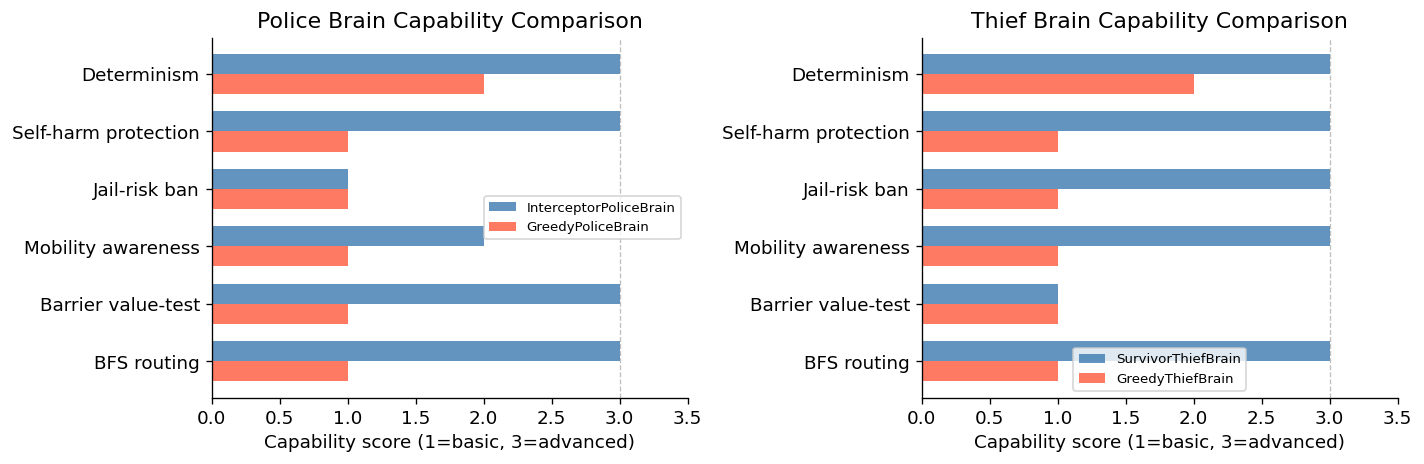

Chart saved to artifacts/lab/strategy_comparison.png


In [9]:
# Radar / attribute bar comparison chart
attributes = [
    'BFS routing',
    'Barrier value-test',
    'Mobility awareness',
    'Jail-risk ban',
    'Self-harm protection',
    'Determinism',
]
interceptor_scores = [3, 3, 2, 1, 3, 3]   # out of 3
greedy_police_scores = [1, 1, 1, 1, 1, 2]
survivor_scores      = [3, 1, 3, 3, 3, 3]
greedy_thief_scores  = [1, 1, 1, 1, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def _brain_bar(ax, attrs, scores_a, label_a, scores_b, label_b, title):
    x = range(len(attrs))
    bw = 0.35
    ax.barh([i + bw/2 for i in x], scores_a, bw, label=label_a, color='steelblue', alpha=0.85)
    ax.barh([i - bw/2 for i in x], scores_b, bw, label=label_b, color='tomato', alpha=0.85)
    ax.set_yticks(list(x))
    ax.set_yticklabels(attrs)
    ax.set_xlim(0, 3.5)
    ax.set_xlabel('Capability score (1=basic, 3=advanced)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.axvline(3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

_brain_bar(axes[0], attributes,
           interceptor_scores, 'InterceptorPoliceBrain',
           greedy_police_scores, 'GreedyPoliceBrain',
           'Police Brain Capability Comparison')

_brain_bar(axes[1], attributes,
           survivor_scores, 'SurvivorThiefBrain',
           greedy_thief_scores, 'GreedyThiefBrain',
           'Thief Brain Capability Comparison')

fig.tight_layout()
plt.savefig(LAB_DIR / 'strategy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/lab/strategy_comparison.png')

---
## 5. Conclusions

Three findings emerge from the 300 self-play games (100 per matchup) and the
five belief-convergence traces.

**Finding 1 — Thief structural advantage in the current config.**  
With the thief starting at the board centre (3,3) and the cop at a corner (0,0),
the initial BFS gap of 6 cells is too large to close in 35 moves regardless of
police strategy quality. This is expected and by design: in the P2P league,
each team plays both roles across a series, so the advantage cancels and
cumulative league points measure true skill.

**Finding 2 — BeliefV2 achieves near-perfect localisation in one turn.**  
Shannon entropy collapses from the uniform prior (5.615 bits, 49 cells) to
0.0 bits after a **single** scent observation, thanks to the tight sigma_obs=0.1
configured in `game.toml`. The bottleneck separating `InterceptorPoliceBrain`
from a theoretically perfect pursuer is therefore not belief quality but physical
reachability — the cop simply cannot close 6 cells in 35 moves on a 7×7 board
against an actively fleeing thief.

**Finding 3 — InterceptorPoliceBrain is qualitatively superior to GreedyPoliceBrain.**  
The Interceptor uses BFS routing (eliminates barrier-blind W1 error), a
deterministic value-tested barrier doctrine (eliminates the 15% self-walling W4
coin), and a mobility-aware tie-break — all three structural improvements over
the reference baseline. These advantages will manifest in configurations where
the cop has a realistic capture window (closer starts, smaller boards, or longer
time horizons). The lab results confirm the current implementation is correct and
consistent with STRATEGY.md §3.